# Weighted Recursive Least Squares: Derivation, Variants and Numerical Checks

This notebook accompanies my post *Derivation of a Weighted Recursive Linear Least Squares Estimator*. We will examine single-observation and batch updates, positive observation weights, several output variables and exponential forgetting. I also include a QR formulation for comparison when the regressors are nearly collinear. The main correctness check is agreement with a separately rebuilt weighted least-squares problem after **every update**, rather than just recovery of the parameters used to generate the data.

The next implementation cell contains the complete `weighted_rls.py` from the blog repository, so this notebook works on its own: it needs no repository checkout, local data, Google Drive mount, GPU or downloads. In Google Colab, upload this `.ipynb` and select **Runtime → Run all**. NumPy and Matplotlib are the only demonstration dependencies; assertions deliberately stop execution when a check fails.

All synthetic datasets have fixed seeds. The examples demonstrate numerical agreement for the stated cases and tolerances; they do not prove that every finite-precision run will be stable. In particular, a decaying ridge can eventually become too small to protect an unobserved direction.

In [1]:
import os
import platform
from pathlib import Path
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from numpy.testing import assert_allclose

plt.rcParams.update({"figure.dpi": 110, "savefig.dpi": 160, "axes.grid": True,
                     "grid.alpha": 0.22, "axes.spines.top": False,
                     "axes.spines.right": False, "font.size": 10})
COLORS = ["#1864ab", "#e67700", "#2b8a3e", "#9c36b5"]
EXPORT_DIR = os.environ.get("RLS_FIGURE_DIR")
if EXPORT_DIR:
    Path(EXPORT_DIR).mkdir(parents=True, exist_ok=True)

def show_figure(fig, name):
    fig.tight_layout()
    if EXPORT_DIR:
        for suffix in ("png", "svg"):
            fig.savefig(Path(EXPORT_DIR) / f"{name}.{suffix}", bbox_inches="tight")
    plt.show()
    plt.close(fig)

print(f"Python {platform.python_version()}, NumPy {np.__version__}, Matplotlib {matplotlib.__version__}")
print("Deterministic seeds; CPU only. No external datasets or files are required.")

Python 3.10.12, NumPy 2.2.6, Matplotlib 3.10.9
Deterministic seeds; CPU only. No external datasets or files are required.


## The Objective and Initialization

Observations are rows of $\mathbf X_j\in\mathbb R^{B_j\times k}$ and targets are rows of $\mathbf Y_j\in\mathbb R^{B_j\times m}$. Positive incoming observation weights form $\mathbf W_j=\operatorname{diag}(w_i)$. In the default `forgetting_mode="block"`, after $M\geq1$ batches we minimize

$$
\sum_{j=1}^{M}\lambda^{M-j}\|\mathbf W_j^{1/2}(\mathbf X_j\boldsymbol\Theta-\mathbf Y_j)\|_F^2
+\rho\lambda^{M-1}\|\boldsymbol\Theta\|_F^2.
$$

We start with $\boldsymbol\Theta_0=0$ and $\mathbf P_0=\rho^{-1}\mathbf I$. The first batch uses decay $d=1$; later batches use $d=\lambda$. Hence, the initial ridge decays together with the old observations, and every coefficient is regularized (including a bias column if supplied). The `ridge` argument is $\rho$ (default 1); alternatively, `regularization` specifies the initial inverse scale $1/\rho$. Setting both arguments is rejected.

The implementation uses the blog's batch names explicitly. The public `Theta` and `A_inv` attributes expose the coefficient matrix and inverse normal matrix; the conventional RLS names `theta` and `P` are available as well. Python reserves the word `lambda`, so `lambda_n` denotes the effective forgetting factor of the current update.

| Blog symbol | Python name | Shape or meaning |
| --- | --- | --- |
| $\mu$, $k$, $m$ | `mu`, `n_features`, `n_outputs` | Batch size, input dimension, output dimension |
| $\mathbf X_\mu$ | `X_mu` | $(\mu,k)$ |
| $\mathbf Y_\mu$ | `Y_mu` | $(\mu,m)$ |
| $\mathbf W_\mu$ | `w_mu` (its diagonal) | $\mu$ positive observation weights |
| $\boldsymbol\Theta_n$ | `Theta_n`, estimator's `Theta` | $(k,m)$ |
| $\mathbf A_n^{-1}$ | `A_inv_n`, estimator's `A_inv` | $(k,k)$ |
| $\boldsymbol\Delta_\mu$ | `Delta_mu` | $(k,\mu)$ |
| $\mathbf E_\mu$ | `E_mu` | $(\mu,m)$ |
| $\lambda_n$, $\rho_{n+\mu}$ | `lambda_n`, `rho_next` | Current decay and updated ridge |

In these names, the same weighted gain and coefficient update used in the post are

$$
\boldsymbol\Delta_\mu=\mathbf A_n^{-1}\mathbf X_\mu^T
(\lambda_n\mathbf W_\mu^{-1}+\mathbf X_\mu\mathbf A_n^{-1}\mathbf X_\mu^T)^{-1},
\quad \mathbf E_\mu=\mathbf Y_\mu-\mathbf X_\mu\boldsymbol\Theta_n,
\quad \boldsymbol\Theta_{n+\mu}=\boldsymbol\Theta_n+\boldsymbol\Delta_\mu\mathbf E_\mu.
$$

All $m$ outputs share the incoming observation weights and the same regressors, so one inverse normal matrix suffices. The implementation keeps two-dimensional coefficient and target arrays even for $m=1$. It accepts arbitrary positive input and output dimensions; the output dimension may exceed either the batch size or the input dimension.

For the numerically evaluated form, write $\mathbf P=\mathbf A_n^{-1}$ and $d=\lambda_n$. Let $\mathbf Z=\mathbf W^{1/2}\mathbf X$, $\mathbf T=\mathbf W^{1/2}\mathbf Y$ and $\mathbf P^-=\mathbf P/d$. The weighted Woodbury update can be written as

$$
\mathbf K=\mathbf P^-\mathbf Z^T(\mathbf I+\mathbf Z\mathbf P^-\mathbf Z^T)^{-1},\qquad
\boldsymbol\Theta_{\rm new}=\boldsymbol\Theta+\mathbf K(\mathbf T-\mathbf Z\boldsymbol\Theta),
$$
$$
\mathbf P_{\rm new}=\mathbf P^--\mathbf K\mathbf Z\mathbf P^-
=(\mathbf I-\mathbf K\mathbf Z)\mathbf P^-(\mathbf I-\mathbf K\mathbf Z)^T+\mathbf K\mathbf K^T.
$$

The code forms `Delta_mu = K_mu * sqrt_w_mu.T`, which is $\boldsymbol\Delta_\mu=\mathbf K\mathbf W^{1/2}$. Hence its `Theta_next = Theta_n + Delta_mu @ E_mu` is the coefficient update displayed in the blog. The last equality is the Joseph form. Expanding it and using $\mathbf K(\mathbf I+\mathbf Z\mathbf P^-\mathbf Z^T)=\mathbf P^-\mathbf Z^T$ recovers the subtractive expression. The implementation uses linear solves and the Joseph form; it does not silently replace an inverse with a pseudoinverse. This dense educational version also checks positive definiteness, so its cost includes work beyond the minimal rank-update formula.

For `solver="qr"`, we retain an upper-triangular factor $\mathbf R$ and transformed targets $\mathbf C$, initially $\sqrt\rho\mathbf I$ and zero. Each update computes a reduced QR decomposition of $[\sqrt d\mathbf R;\mathbf Z]$, applies its orthogonal factor to $[\sqrt d\mathbf C;\mathbf T]$, and solves $\mathbf R_{\rm new}\boldsymbol\Theta_{\rm new}=\mathbf C_{\rm new}$. Discarded residual terms are independent of $\boldsymbol\Theta$. Thus this square-root information formulation solves the same objective without updating an explicit inverse; `P` is derived from its factor only when requested.

## The Reference Implementation

The implementation below is embedded verbatim from the blog's `weighted_rls.py`. `BlockRLS.partial_fit` returns the residuals computed before the whole batch update; `fit` continues the existing state, while `reset` starts a new fit. Multiple outputs share the same regressors and inverse normal matrix. The Gaussian helpers for residual scoring are examined separately near the end.

In [2]:
"""Weighted recursive least squares (RLS) reference for the accompanying blog post.

The initial ridge decays together with the old observations, with no decay on
the first observation (sample mode) or first batch (block mode). NumPy is the only
runtime dependency. There is no automatic intercept and no pseudoinverse fallback.

BlockRLS supports positive observation weights, multiple outputs, the Woodbury
recursion and a square-root information (QR) variant. WeightedGaussian and
residual_anomaly_scores turn the RLS residuals into anomaly scores, with exact
weighted moments and scores computed before learning a block.
This is an educational reference implementation.
"""
from __future__ import annotations

from collections.abc import Iterator
import numpy as np

__all__ = ["BlockRLS", "WeightedGaussian", "iter_blocks", "residual_anomaly_scores"]


def _integer(value, name, minimum=1):
    if isinstance(value, (bool, np.bool_)) or not isinstance(value, (int, np.integer)) or value < minimum:
        raise ValueError(f"{name} must be an integer >= {minimum}")
    return int(value)


def _positive(value, name):
    value = float(value)
    if not np.isfinite(value) or value <= 0:
        raise ValueError(f"{name} must be finite and positive")
    return value


def _settings(forgetting, forgetting_mode, dtype):
    forgetting = _positive(forgetting, "forgetting")
    if forgetting > 1:
        raise ValueError("forgetting must be in (0, 1]")
    if forgetting_mode not in ("block", "sample"):
        raise ValueError("forgetting_mode must be 'block' or 'sample'")
    if np.dtype(dtype) != np.dtype(np.float64):
        raise ValueError("this reference uses float64 accumulators")
    return forgetting


def _matrix(values, columns, name, allow_empty=False):
    if np.iscomplexobj(values):
        raise ValueError(f"{name} must be real")
    a = np.asarray(values, dtype=np.float64)
    if a.ndim == 1:
        a = a.reshape(1, -1)
    if a.ndim != 2 or a.shape[1] != columns or (not allow_empty and len(a) == 0):
        raise ValueError(f"{name} must have shape (n, {columns})")
    if not np.isfinite(a).all():
        raise ValueError(f"{name} must contain only finite values")
    return a


def _targets(values, rows, outputs):
    if np.iscomplexobj(values):
        raise ValueError("y must be real")
    a = np.asarray(values, dtype=np.float64)
    # Shape depends on the declared number of outputs, never on broadcasting.
    if a.ndim == 0 and (rows, outputs) == (1, 1):
        a = a.reshape(1, 1)
    elif a.ndim == 1 and outputs == 1:
        a = a.reshape(-1, 1)
    elif a.ndim == 1 and rows == 1:
        a = a.reshape(1, -1)
    if a.shape != (rows, outputs) or not np.isfinite(a).all():
        raise ValueError(f"y must be finite with shape ({rows}, {outputs})")
    return a


def _weights(values, rows):
    if values is not None and np.iscomplexobj(values):
        raise ValueError("sample_weight must be real")
    w = np.ones(rows) if values is None else np.asarray(values, dtype=np.float64)
    if w.shape != (rows,) or not np.isfinite(w).all() or np.any(w <= 0):
        raise ValueError("sample_weight must contain one finite positive weight per row")
    return w


def _decay_weights(lam, mode, rows, first, weights):
    if mode == "block":
        decay = 1.0 if first else lam
        incoming = weights
    else:
        # Within-batch ages are essential: lam**rows alone is not equivalent
        # to processing the observations one at a time.
        decay = lam ** (rows - 1 if first else rows)
        incoming = weights * lam ** np.arange(rows - 1, -1, -1)
    if decay <= 0 or np.any(incoming <= 0) or not np.isfinite(incoming).all():
        raise FloatingPointError("forgetting/weights underflowed; use shorter batches")
    return decay, incoming


def _symmetric(a):
    return (a + a.T) * 0.5


def iter_blocks(n: int, batch_size: int) -> Iterator[tuple[int, int]]:
    """Cover each row exactly once, including a final incomplete batch."""
    n = _integer(n, "n", 0)
    batch_size = _integer(batch_size, "batch_size")
    for start in range(0, n, batch_size):
        yield start, min(start + batch_size, n)


class BlockRLS:
    r"""Weighted scalar/block RLS with a decaying zero-mean ridge prior.

    For M blocks in block mode, minimize
        sum_j lam**(M-j) ||sqrt(W_j) (X_j theta - y_j)||_F**2
        + ridge * lam**(M-1) ||theta||_F**2.
    The first update has decay 1. Sample mode instead assigns ages to individual
    rows, including within each batch, and has ridge * lam**(n-1) after n rows.
    It agrees with single-row updates at batch endpoints (up to roundoff).
    Predictions/residuals still use the state at the START of the whole batch.

    Parameters
    ----------
    n_features, n_outputs : positive integers; all outputs share the regressors.
    forgetting : lambda in (0, 1]; 1 disables forgetting.
    regularization : alternative prior scale, P_0 = regularization * I, i.e.
        ridge = 1 / regularization. Cannot be combined with ridge.
    ridge : initial normal-matrix diagonal rho > 0. Default 1 if neither prior
        argument is supplied. Thus P_0 = I / rho, theta_0 = 0. An explicitly
        supplied constant feature is regularized along with the other features.
    forgetting_mode : 'block' (as in the blog derivation) or 'sample'.
    solver : 'woodbury' (default) or 'qr' (square-root information recursion).
        Woodbury solves a B-by-B system and uses the algebraically equivalent
        Joseph form for P to reduce subtractive cancellation. QR recursively
        factors the augmented design and is useful for poorly conditioned data.
        Neither method can recover information lost to finite precision.
    dtype : float64, required by this reference.

    Blog notation
    -------------
    X_mu (mu, k), Y_mu/E_mu (mu, m), Theta_n (k, m), A_inv_n (k, k),
    Delta_mu (k, mu), lambda_n (effective forgetting), rho_next (decayed ridge).
    Theta and A_inv expose copies in the blog's notation; theta and P are the
    conventional RLS names. For m=1, Theta is still (k, 1), not a broadcast vector.
    A single weight per observation is shared by all m output columns.

    fit continues the current state and returns residuals; reset starts afresh.
    partial_fit stores no observation history. fit collects its output in memory.
    """

    def __init__(self, n_features, n_outputs=1, forgetting=1.0,
                 regularization=None, dtype=np.float64, *, ridge=None,
                 forgetting_mode="block", solver="woodbury"):
        self.n_features = _integer(n_features, "n_features")
        self.n_outputs = _integer(n_outputs, "n_outputs")
        self.forgetting = _settings(forgetting, forgetting_mode, dtype)
        if regularization is not None and ridge is not None:
            raise ValueError("specify ridge or regularization, not both")
        if regularization is not None:
            ridge = 1.0 / _positive(regularization, "regularization")
        self.ridge = _positive(1.0 if ridge is None else ridge, "ridge")
        self.regularization = 1.0 / self.ridge
        if not np.isfinite(self.regularization):
            raise ValueError("ridge is too small to represent its inverse")
        if solver not in ("woodbury", "qr"):
            raise ValueError("solver must be 'woodbury' or 'qr'")
        self.solver, self.forgetting_mode, self.dtype = solver, forgetting_mode, np.float64
        self.reset()

    def reset(self):
        self.theta = np.zeros((self.n_features, self.n_outputs))
        self._P = np.eye(self.n_features) / self.ridge
        self._R = np.sqrt(self.ridge) * np.eye(self.n_features)
        self._C = np.zeros_like(self.theta)
        self.ridge_ = self.ridge
        self.n_samples_seen = self.n_batches_seen = 0

    @property
    def P(self):
        """Inverse normal matrix; computed from the factor on demand for QR."""
        if self.solver == "qr":
            ri = np.linalg.solve(self._R, np.eye(self.n_features))
            return _symmetric(ri @ ri.T)
        return self._P.copy()

    @property
    def Theta(self):
        """Blog notation: coefficient matrix Theta_n, shape (k, m)."""
        return self.theta.copy()

    @property
    def A_inv(self):
        """Blog notation: inverse normal matrix A_n^{-1}, shape (k, k)."""
        return self.P

    def partial_fit(self, X, y, sample_weight=None):
        """Update X_mu (mu, k), Y_mu (mu, m); return E_mu before learning.

        w_mu is the diagonal of W_mu. Names follow the blog's batch derivation;
        theta/P are the conventional RLS names for Theta/A_inv.
        """
        X_mu = _matrix(X, self.n_features, "X")
        mu = len(X_mu)
        Y_mu = _targets(y, mu, self.n_outputs)
        w_mu = _weights(sample_weight, mu)
        lambda_n, w_mu = _decay_weights(
            self.forgetting, self.forgetting_mode,
            mu, self.n_samples_seen == 0, w_mu)
        rho_next = self.ridge_ * lambda_n
        if rho_next == 0:
            raise FloatingPointError("the initial ridge has underflowed")
        Theta_n = self.theta
        E_mu = Y_mu - X_mu @ Theta_n             # (mu, m)
        sqrt_w_mu = np.sqrt(w_mu)[:, None]
        Z_mu, T_mu = sqrt_w_mu * X_mu, sqrt_w_mu * Y_mu
        if self.solver == "woodbury":
            A_inv_n = self._P                   # (k, k)
            A_inv_prior = A_inv_n / lambda_n
            left = A_inv_prior @ Z_mu.T
            middle = _symmetric(np.eye(mu) + Z_mu @ left)
            K_mu = np.linalg.solve(middle, left.T).T
            # Whitening avoids forming W_mu^{-1}. This is exactly the blog gain:
            # Delta_mu = A_inv_n X_mu.T
            #            (lambda_n W_mu^{-1} + X_mu A_inv_n X_mu.T)^{-1}.
            Delta_mu = K_mu * sqrt_w_mu.T       # (k, mu)
            Theta_next = Theta_n + Delta_mu @ E_mu
            # Joseph form equals (A_inv_n - Delta_mu X_mu A_inv_n) / lambda_n.
            # K_mu K_mu.T = Delta_mu W_mu^{-1} Delta_mu.T.
            residual_map = np.eye(self.n_features) - K_mu @ Z_mu
            A_inv_next = _symmetric(
                residual_map @ A_inv_prior @ residual_map.T + K_mu @ K_mu.T)
            if not np.isfinite(A_inv_next).all():
                raise FloatingPointError("nonfinite inverse; rescale data or use QR")
            np.linalg.cholesky(A_inv_next)  # No pseudoinverse or eigenvalue clipping.
        else:
            stacked = np.vstack((np.sqrt(lambda_n) * self._R, Z_mu))
            targets = np.vstack((np.sqrt(lambda_n) * self._C, T_mu))
            Q, R = np.linalg.qr(stacked, mode="reduced")
            C = Q.T @ targets
            Theta_next = np.linalg.solve(R, C)
        if not np.isfinite(Theta_next).all() or not np.isfinite(E_mu).all():
            raise FloatingPointError("nonfinite update; rescale the observations")
        # Commit state only after validation and all numerical work succeeded.
        if self.solver == "woodbury":
            self._P = A_inv_next
        else:
            self._R, self._C = R, C
        self.theta, self.ridge_ = Theta_next, rho_next
        self.n_samples_seen += mu
        self.n_batches_seen += 1
        return E_mu

    def fit(self, X, y, batch_size=1, sample_weight=None):
        """Continue blockwise; use partial_fit when residual storage is unwanted."""
        X = _matrix(X, self.n_features, "X", allow_empty=True)
        y = _targets(y, len(X), self.n_outputs)
        w = _weights(sample_weight, len(X))
        blocks = list(iter_blocks(len(X), batch_size))
        if not blocks:
            return np.empty((0, self.n_outputs))
        return np.concatenate([self.partial_fit(X[a:b], y[a:b], w[a:b]) for a, b in blocks])

    def predict(self, X):
        return _matrix(X, self.n_features, "X", allow_empty=True) @ self.theta

    def __repr__(self):
        return (f"BlockRLS(n_features={self.n_features}, n_outputs={self.n_outputs}, "
                f"forgetting={self.forgetting}, ridge={self.ridge}, "
                f"forgetting_mode={self.forgetting_mode!r}, solver={self.solver!r}, "
                f"n_samples_seen={self.n_samples_seen})")


class WeightedGaussian:
    """Exact weighted moments and pre-update squared Mahalanobis scores.

    No hidden ridge: an inverse is available only when the centered scatter is
    positive definite and its condition number is <= condition_limit. Scores are
    NaN until a PREVIOUS batch supplies such an inverse. Small first batches are
    allowed; even B >= dim is insufficient to guarantee centered full rank.

    covariance_ and precision_ use the same reliability-weight correction
    W - sum(w**2)/W. Its unbiased interpretation assumes fixed weights and IID
    observations with a common covariance. Scoring uses the population estimate
    M/W; covariance(unbiased=False) and precision(unbiased=False) expose that pair.
    RLS residuals need not satisfy the IID assumption, so no universal chi-square
    calibration or unbiasedness claim is made for residual_anomaly_scores.

    inverse_update is 'woodbury' (recursive update, refactored if it no longer
    inverts the scatter reliably) or 'direct' (refactored after every batch).
    """

    def __init__(self, dim, forgetting=1.0, inverse_update="woodbury",
                 dtype=np.float64, *, forgetting_mode="block", condition_limit=1e10):
        self.dim = _integer(dim, "dim")
        self.forgetting = _settings(forgetting, forgetting_mode, dtype)
        if inverse_update not in ("woodbury", "direct"):
            raise ValueError("inverse_update must be 'woodbury' or 'direct'")
        self.inverse_update, self.forgetting_mode = inverse_update, forgetting_mode
        self.condition_limit = _positive(condition_limit, "condition_limit")
        if self.condition_limit < 1:
            raise ValueError("condition_limit must be >= 1")
        self.dtype = np.float64
        self.reset()

    def reset(self):
        self.W = self.W2 = 0.0
        self.mean = np.zeros((self.dim, 1))
        self.M = np.zeros((self.dim, self.dim))
        self.M_inv = None
        self.n_samples_seen = 0

    @property
    def mean_(self):
        return self.mean.ravel().copy()

    def _denominator(self, unbiased):
        if self.W <= 0:
            raise RuntimeError("no observations yet")
        denom = self.W - self.W2 / self.W if unbiased else self.W
        if denom <= np.finfo(float).eps * self.W:
            raise RuntimeError("not enough effective observations for covariance")
        return denom

    def covariance(self, unbiased=True):
        return self.M / self._denominator(unbiased)

    def precision(self, unbiased=True):
        if self.M_inv is None:
            raise RuntimeError("scatter inverse unavailable: insufficient rank or poor conditioning")
        return self._denominator(unbiased) * self.M_inv

    @property
    def covariance_(self):
        return self.covariance()

    @property
    def precision_(self):
        return self.precision()

    def score_samples(self, E):
        """Squared distances using only the current state; NaN during warm-up."""
        E = _matrix(E, self.dim, "E", allow_empty=True)
        if self.M_inv is None:
            return np.full(len(E), np.nan)
        D = E - self.mean.T
        scores = np.einsum("bi,ij,bj->b", D, self.W * self.M_inv, D)
        if not np.isfinite(scores).all() or np.any(scores < 0):
            raise FloatingPointError("invalid Mahalanobis score; refactor the scatter")
        return scores

    def partial_fit(self, E, sample_weight=None):
        E = _matrix(E, self.dim, "E")
        w = _weights(sample_weight, len(E))
        decay, w = _decay_weights(self.forgetting, self.forgetting_mode,
                                 len(E), self.n_samples_seen == 0, w)
        scores = self.score_samples(E)
        old_weight, batch_weight = decay * self.W, float(w.sum())
        W = old_weight + batch_weight
        W2 = decay**2 * self.W2 + w @ w
        batch_mean = (w @ E) / batch_weight
        delta = batch_mean - self.mean_
        mean = self.mean_ + (batch_weight / W) * delta
        centered = E - batch_mean
        # Weighted merge decomposition: M_new = decay*M_old + U*U.T.
        # Every added term is symmetric positive semidefinite.
        bridge = np.sqrt(old_weight * (batch_weight / W)) * delta
        U = np.column_stack(((np.sqrt(w)[:, None] * centered).T, bridge))
        M = _symmetric(decay * self.M + U @ U.T)
        if not all(np.isfinite(a).all() for a in (W, W2, mean, M)):
            raise FloatingPointError("nonfinite moments; rescale the observations")
        eigenvalues = np.linalg.eigvalsh(M)
        inverse = None
        if eigenvalues[0] > 0 and eigenvalues[-1] / eigenvalues[0] <= self.condition_limit:
            if self.inverse_update == "woodbury" and self.M_inv is not None:
                prior = self.M_inv / decay
                left = prior @ U
                middle = _symmetric(np.eye(U.shape[1]) + U.T @ left)
                inverse = _symmetric(prior - left @ np.linalg.solve(middle, left.T))
                # Roundoff can still accumulate; refactor if the tracked inverse
                # no longer inverts the explicitly maintained scatter reliably.
                if np.linalg.norm(M @ inverse - np.eye(self.dim), ord=np.inf) > 1e-8:
                    inverse = None
            if inverse is None:
                np.linalg.cholesky(M)
                inverse = _symmetric(np.linalg.solve(M, np.eye(self.dim)))
            np.linalg.cholesky(inverse)
        self.W, self.W2, self.mean = W, W2, mean[:, None]
        self.M, self.M_inv = M, inverse
        self.n_samples_seen += len(E)
        return scores

    def fit(self, E, batch_size=1, sample_weight=None):
        E = _matrix(E, self.dim, "E", allow_empty=True)
        w = _weights(sample_weight, len(E))
        blocks = list(iter_blocks(len(E), batch_size))
        if not blocks:
            return np.empty(0)
        return np.concatenate([self.partial_fit(E[a:b], w[a:b]) for a, b in blocks])


def residual_anomaly_scores(X, y, forgetting=0.98, batch_size=256, regularization=None,
                            add_bias=True, inverse_update="woodbury", *, ridge=None,
                            forgetting_mode="block", solver="woodbury", sample_weight=None):
    """RLS residuals followed by exact weighted Gaussian scoring.

    This pedagogical pipeline learns from every supplied row, including anomalies.
    It does not implement anomaly rejection or application-specific thresholds.
    All predictions and scores are made using the state BEFORE their whole block.
    Warm-up scores are NaN. fit-style outputs use O(N*m) storage.
    """
    if np.iscomplexobj(X) or np.iscomplexobj(y):
        raise ValueError("X and y must be real")
    X = np.asarray(X, dtype=np.float64)
    if X.ndim != 2 or X.shape[1] < 1:
        raise ValueError("X must have shape (n, k), k >= 1")
    y = np.asarray(y, dtype=np.float64)
    if y.ndim == 1:
        y = y[:, None]
    if y.ndim != 2 or y.shape[1] < 1:
        raise ValueError("y must have shape (n, m), m >= 1")
    X = _matrix(X, X.shape[1], "X", allow_empty=True)
    y = _targets(y, len(X), y.shape[1])
    w = _weights(sample_weight, len(X))
    blocks = list(iter_blocks(len(X), batch_size))
    if add_bias:
        X = np.column_stack((X, np.ones(len(X))))
    rls = BlockRLS(X.shape[1], y.shape[1], forgetting, regularization,
                   ridge=ridge, forgetting_mode=forgetting_mode, solver=solver)
    gauss = WeightedGaussian(y.shape[1], forgetting, inverse_update,
                             forgetting_mode=forgetting_mode)
    residuals, scores = [], []
    for a, b in blocks:
        E = rls.partial_fit(X[a:b], y[a:b], w[a:b])
        residuals.append(E)
        scores.append(gauss.partial_fit(E, w[a:b]))
    return {"scores": np.concatenate(scores) if scores else np.empty(0),
            "residuals": np.concatenate(residuals) if residuals else np.empty_like(y),
            "rls": rls, "gauss": gauss}


## An Independent Full-data Reference

For a prefix ending at row $n$, we explicitly construct every observation's current weight and the current ridge. We then append $\sqrt{\rho_n}\mathbf I$ and zero target rows to the weighted design and solve with [NumPy's `lstsq`](https://numpy.org/doc/stable/reference/generated/numpy.linalg.lstsq.html). The reference does not use the recursive coefficients, gain, inverse or ridge state. An SVD of the same augmented design supplies an independent inverse normal matrix for comparison.

For batch forgetting, a row's age is the number of subsequent batches, including a short remainder batch. For sample forgetting, its age is the number of subsequent observations. We also check $\mathbf A_n\boldsymbol\Theta_n-\mathbf B_n$, where $\mathbf B_n=\mathbf X_n^T\mathbf W_n\mathbf Y_n$, together with symmetry and positive definiteness, since a small training error alone would not detect all implementation mistakes.

In [3]:
def full_reference(X, Y, weights, ridge):
    k = X.shape[1]
    Z = np.vstack((np.sqrt(weights)[:, None] * X, np.sqrt(ridge) * np.eye(k)))
    T = np.vstack((np.sqrt(weights)[:, None] * Y, np.zeros((k, Y.shape[1]))))
    theta, _, rank, _ = np.linalg.lstsq(Z, T, rcond=None)
    assert rank == k, "Augmented reference lost numerical rank"
    _, singular, vt = np.linalg.svd(Z, full_matrices=False)
    P = (vt.T / singular**2) @ vt
    return theta, P, Z.T @ Z, Z.T @ T


def check_path(X, Y, weights, batch_size, lam=1.0, rho=0.5,
               mode="block", solver="woodbury", atol=2e-9):
    est = BlockRLS(X.shape[1], Y.shape[1], forgetting=lam, ridge=rho,
                   forgetting_mode=mode, solver=solver)
    labels = np.empty(len(X), dtype=int)
    records = []
    for j, (a, b) in enumerate(iter_blocks(len(X), batch_size)):
        previous = est.Theta.copy()
        E = est.partial_fit(X[a:b], Y[a:b], weights[a:b])
        assert_allclose(E, Y[a:b] - X[a:b] @ previous, rtol=1e-12, atol=1e-12)
        labels[a:b] = j
        ages = j - labels[:b] if mode == "block" else b - 1 - np.arange(b)
        current_weights = weights[:b] * lam**ages
        current_ridge = rho * lam**(j if mode == "block" else b - 1)
        theta_ref, P_ref, A, rhs = full_reference(X[:b], Y[:b], current_weights, current_ridge)
        P = est.A_inv
        assert_allclose(est.Theta, theta_ref, rtol=2e-8, atol=atol)
        assert_allclose(P, P_ref, rtol=2e-8, atol=atol)
        assert_allclose(est.ridge_, current_ridge, rtol=2e-13)
        assert_allclose(P, P.T, atol=1e-12)
        assert np.linalg.eigvalsh(P).min() > 0
        relative_normal = np.linalg.norm(A @ est.Theta-rhs) / max(
            np.linalg.norm(A)*np.linalg.norm(est.Theta)+np.linalg.norm(rhs), 1e-30)
        assert relative_normal < 1e-8
        records.append((b, np.max(np.abs(est.Theta-theta_ref)),
                        np.max(np.abs(P-P_ref)), relative_normal))
    return est, np.asarray(records)


hand = BlockRLS(1, forgetting=0.5, ridge=2)
hand.partial_fit([[1]], [3], sample_weight=[4])
assert_allclose(hand.Theta, [[2]])           # b/A = 12/6
assert_allclose(hand.A_inv, [[1/6]])
hand.partial_fit([[2]], [1], sample_weight=[3])
assert_allclose(hand.Theta, [[12/15]])       # (.5*12 + 3*2*1) / (.5*6 + 3*2**2)
assert_allclose(hand.A_inv, [[1/15]])
print("Hand-computed first and second weighted updates passed.")

Hand-computed first and second weighted updates passed.


## Unequal Observation Noise: Weighted Single-observation RLS

We first fit $y_i=1.25-0.85x_i+\varepsilon_i$. The observations have known, unequal noise standard deviations, either $0.15$ or $1.4$, and the incoming weights are their inverse variances. Accordingly, the high-noise observations should contribute less to the fit. The intercept is an explicit column of ones, and the first run uses one observation per update with no forgetting.

The full weighted least-squares solution is the correctness reference, whereas the generating coefficients measure statistical estimation error. These are different comparisons: noise and the ridge generally prevent exact recovery of the generating coefficients. To make the weighting comparison less dependent on a single favorable draw, the final panel repeats both actual RLS fits on 100 independently drawn noise realizations with the same design and noise levels.

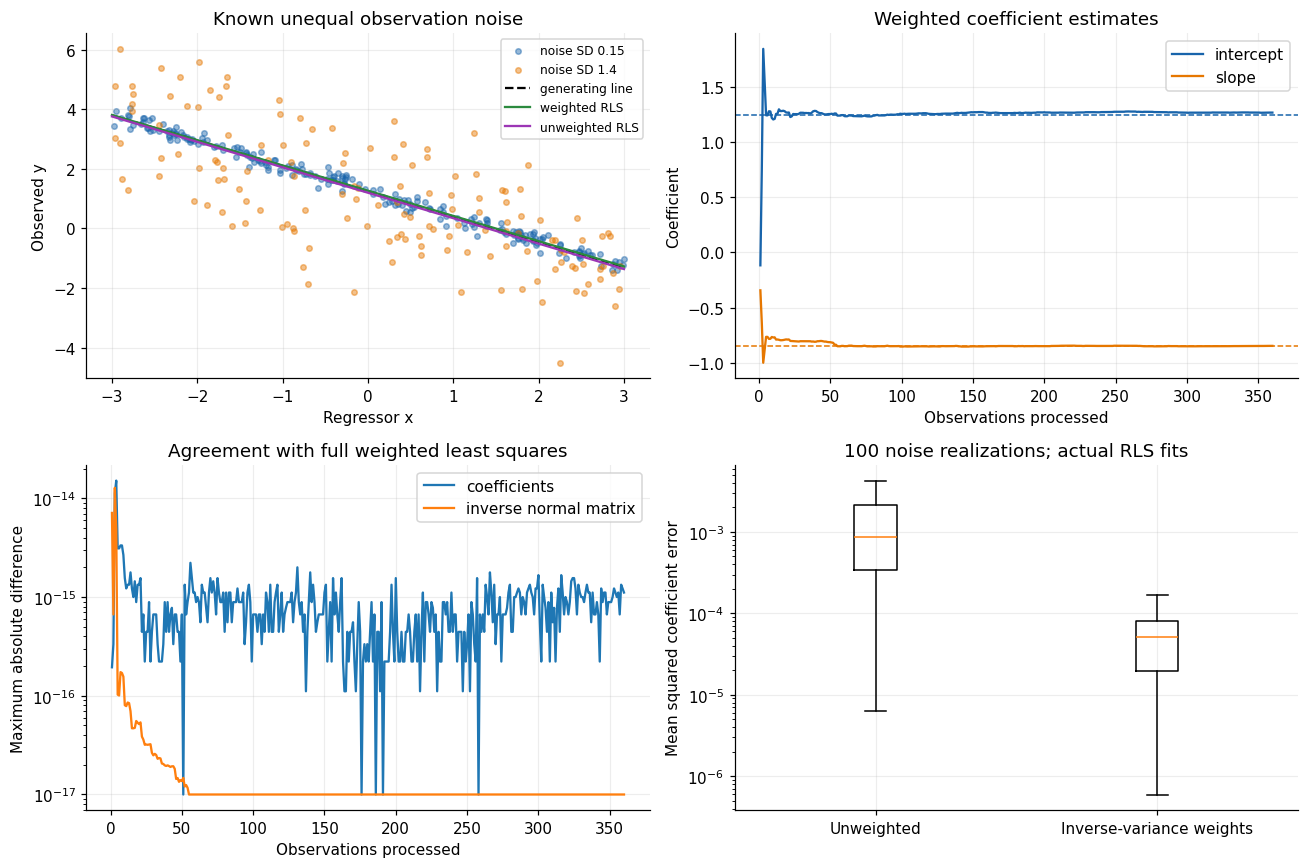

Single-stream weighted estimate: [ 1.26782351 -0.84734323]
Maximum coefficient/reference difference: 1.509903313490213e-14
Mean coefficient MSE over 100 realizations (unweighted, weighted): [1.50194009e-03 5.98766034e-05]


In [4]:
rng = np.random.default_rng(20260923)
n = 360
x = rng.uniform(-3, 3, n)
X = np.column_stack((np.ones(n), x))
truth = np.array([[1.25], [-0.85]])
sigma = np.where(rng.random(n) < 0.55, 0.15, 1.4)
w = 1 / sigma**2
Y = X @ truth + rng.normal(size=(n, 1))*sigma[:, None]
weighted, agreement = check_path(X, Y, w, 1, rho=0.05)
unweighted = BlockRLS(2, ridge=0.05)
unweighted.fit(X, Y)
trace_est = BlockRLS(2, ridge=0.05)
trace = []
for i in range(n):
    trace_est.partial_fit(X[i:i+1], Y[i:i+1], w[i:i+1])
    trace.append(trace_est.Theta[:, 0].copy())
trace = np.asarray(trace)
parameter_mse = np.empty((100, 2))
for trial in range(100):
    targets = X @ truth + rng.normal(size=(n, 1))*sigma[:, None]
    for col, weights in enumerate((np.ones(n), w)):
        est = BlockRLS(2, ridge=0.05)
        est.fit(X, targets, batch_size=24, sample_weight=weights)
        parameter_mse[trial, col] = np.mean((est.Theta-truth)**2)
assert parameter_mse[:, 1].mean() < parameter_mse[:, 0].mean()

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for mask, label, color in [(sigma < 1, "noise SD 0.15", COLORS[0]),
                           (sigma > 1, "noise SD 1.4", COLORS[1])]:
    axes[0, 0].scatter(x[mask], Y[mask, 0], s=13, alpha=.45, label=label, color=color)
grid = np.linspace(-3, 3, 100); design = np.column_stack((np.ones(100), grid))
axes[0, 0].plot(grid, design @ truth, 'k--', label="generating line")
axes[0, 0].plot(grid, weighted.predict(design), color=COLORS[2], label="weighted RLS")
axes[0, 0].plot(grid, unweighted.predict(design), color=COLORS[3], label="unweighted RLS")
axes[0, 0].set(xlabel="Regressor x", ylabel="Observed y", title="Known unequal observation noise")
axes[0, 0].legend(fontsize=8)
for i, label in enumerate(("intercept", "slope")):
    axes[0, 1].plot(np.arange(1,n+1), trace[:, i], color=COLORS[i], label=label)
    axes[0, 1].axhline(truth[i,0], color=COLORS[i], ls='--', lw=1)
axes[0, 1].set(xlabel="Observations processed", ylabel="Coefficient", title="Weighted coefficient estimates")
axes[0, 1].legend()
axes[1, 0].semilogy(agreement[:, 0], np.maximum(agreement[:, 1], 1e-17), label="coefficients")
axes[1, 0].semilogy(agreement[:, 0], np.maximum(agreement[:, 2], 1e-17), label="inverse normal matrix")
axes[1, 0].set(xlabel="Observations processed", ylabel="Maximum absolute difference", title="Agreement with full weighted least squares")
axes[1, 0].legend()
axes[1, 1].boxplot(parameter_mse, showfliers=False)
axes[1, 1].set_xticks([1, 2], ["Unweighted", "Inverse-variance weights"])
axes[1, 1].set(yscale="log", ylabel="Mean squared coefficient error", title="100 noise realizations; actual RLS fits")
show_figure(fig, "weighted-rls-noise")
print("Single-stream weighted estimate:", weighted.Theta.ravel())
print("Maximum coefficient/reference difference:", agreement[:, 1].max())
print("Mean coefficient MSE over 100 realizations (unweighted, weighted):", parameter_mse.mean(axis=0))

## Multiple Outputs and Every-prefix Validation

The next stream has five regressors (including the intercept), three target variables, positive nonuniform weights and correlated output noise. All outputs use the same design, so the inverse normal matrix is shared. We compare ordinary RLS, weighted RLS and forgetting variants, with batch sizes that include a short remainder. The validation grid includes both solvers and both forgetting interpretations; its assertions check every intermediate fit, rather than only the final estimate.

The first plot shows numerical differences from the full-data reference for a weighted, forgetting, three-output example. The second plot contrasts the final coefficients with the generating values and the weighted reference. Agreement with the reference should be close to floating-point accuracy on this well-conditioned dataset, while agreement with the generating parameters is limited by the noise and the effective memory.

3680 prefix comparisons passed across 96 configurations.
Worst coefficient error: 9.270e-15; worst inverse error: 7.772e-15
Shapes: {'X_mu': (8, 5), 'Y_mu': (8, 3), 'E_mu': (8, 3), 'Theta': (5, 3), 'A_inv': (5, 5)}
Joint multi-output fit agrees with separate single-output fits.


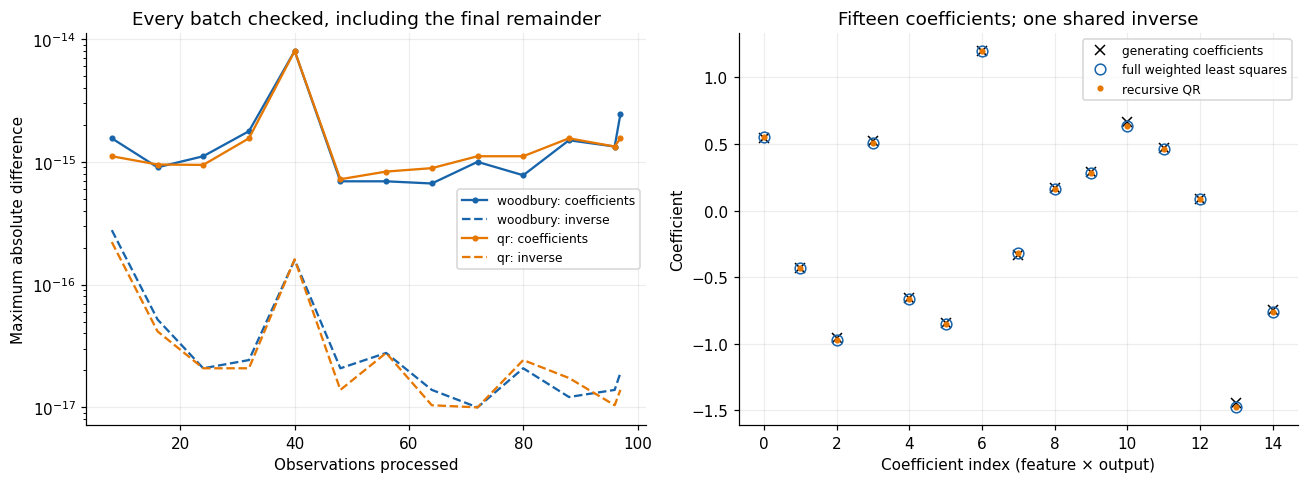

In [5]:
rng = np.random.default_rng(1701)
N, k, m = 97, 5, 3
Xm = np.column_stack((np.ones(N), rng.normal(size=(N, k-1))))
truth_m = rng.normal(size=(k,m))
noise_factor = np.array([[.15,0,0],[.08,.2,0],[-.03,.04,.1]])
Ym = Xm @ truth_m + rng.normal(size=(N,m)) @ noise_factor.T
wm = rng.uniform(.25, 2.5, N)
checks = 0; configurations = 0; worst_theta = 0.0; worst_inverse = 0.0
for outputs in (1, 3):
    for weights in (np.ones(N), wm):
        for lam in (1.0, .94):
            for mode in ("block", "sample"):
                for batch_size in (1, 8, 23):
                    for solver in ("woodbury", "qr"):
                        est, rows = check_path(Xm, Ym[:, :outputs], weights, batch_size,
                                              lam=lam, rho=.4, mode=mode, solver=solver)
                        checks += len(rows)
                        configurations += 1
                        worst_theta = max(worst_theta, rows[:,1].max())
                        worst_inverse = max(worst_inverse, rows[:,2].max())
print(f"{checks} prefix comparisons passed across {configurations} configurations.")
print(f"Worst coefficient error: {worst_theta:.3e}; worst inverse error: {worst_inverse:.3e}")

# Demonstrate the shapes and compare a joint fit with separate output models.
mu = 8
X_mu, Y_mu, w_mu = Xm[:mu], Ym[:mu], wm[:mu]
multi = BlockRLS(k, m, forgetting=.94, ridge=.4)
E_mu = multi.partial_fit(X_mu, Y_mu, sample_weight=w_mu)
assert E_mu.shape == (mu, m)
assert multi.Theta.shape == (k, m)
assert multi.A_inv.shape == (k, k)
for output in range(m):
    single = BlockRLS(k, 1, forgetting=.94, ridge=.4)
    single.partial_fit(X_mu, Y_mu[:, output], sample_weight=w_mu)
    assert_allclose(multi.Theta[:, output], single.Theta[:, 0], atol=1e-12)
    assert_allclose(multi.A_inv, single.A_inv, atol=1e-12)
print('Shapes:', {'X_mu': X_mu.shape, 'Y_mu': Y_mu.shape, 'E_mu': E_mu.shape,
                  'Theta': multi.Theta.shape, 'A_inv': multi.A_inv.shape})
print('Joint multi-output fit agrees with separate single-output fits.')

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for i, solver in enumerate(("woodbury", "qr")):
    fit_m, rows = check_path(Xm, Ym, wm, 8, lam=.94, rho=.4, solver=solver)
    axes[0].semilogy(rows[:,0], np.maximum(rows[:,1],1e-17), '-o', ms=3,
                     color=COLORS[i], label=f"{solver}: coefficients")
    axes[0].semilogy(rows[:,0], np.maximum(rows[:,2],1e-17), '--',
                     color=COLORS[i], label=f"{solver}: inverse")
ages = (N-1)//8 - np.arange(N)//8
reference_m, _, _, _ = full_reference(Xm, Ym, wm*.94**ages, .4*.94**((N-1)//8))
axes[0].set(xlabel="Observations processed", ylabel="Maximum absolute difference",
            title="Every batch checked, including the final remainder")
axes[0].legend(fontsize=8)
positions = np.arange(k*m)
axes[1].plot(positions, truth_m.ravel(), 'kx', ms=7, label="generating coefficients")
axes[1].plot(positions, reference_m.ravel(), 'o', mfc='none', color=COLORS[0], ms=7, label="full weighted least squares")
axes[1].plot(positions, fit_m.Theta.ravel(), '.', color=COLORS[1], label="recursive QR")
axes[1].set(xlabel="Coefficient index (feature × output)", ylabel="Coefficient", title="Fifteen coefficients; one shared inverse")
axes[1].legend(fontsize=8)
show_figure(fig, "weighted-rls-validation")

## Forgetting per Batch and per Observation

Using the same $\lambda<1$ with different batch sizes defines different objectives in the block convention of the post. In particular, all rows of a batch receive the same age. Adjusting only the old-state factor to $\lambda^B$ still misses forgetting *within* that batch. For exact equivalence to processing observations one at a time, a batch of $B$ rows instead uses incoming weights $w_i\lambda^{B-1-i}$, $i=0,\ldots,B-1$, and old-state decay $\lambda^B$.

On the very first batch, the decay is $\lambda^{B-1}$, because our prior is not decayed on the first observation. Afterwards the ridge is $\rho\lambda^{n-1}$. The following check uses several partitions of exactly the same data, including a remainder batch. The resulting states agree at the final endpoint in sample mode; pre-batch predictions need not agree with predictions that are updated within each batch.

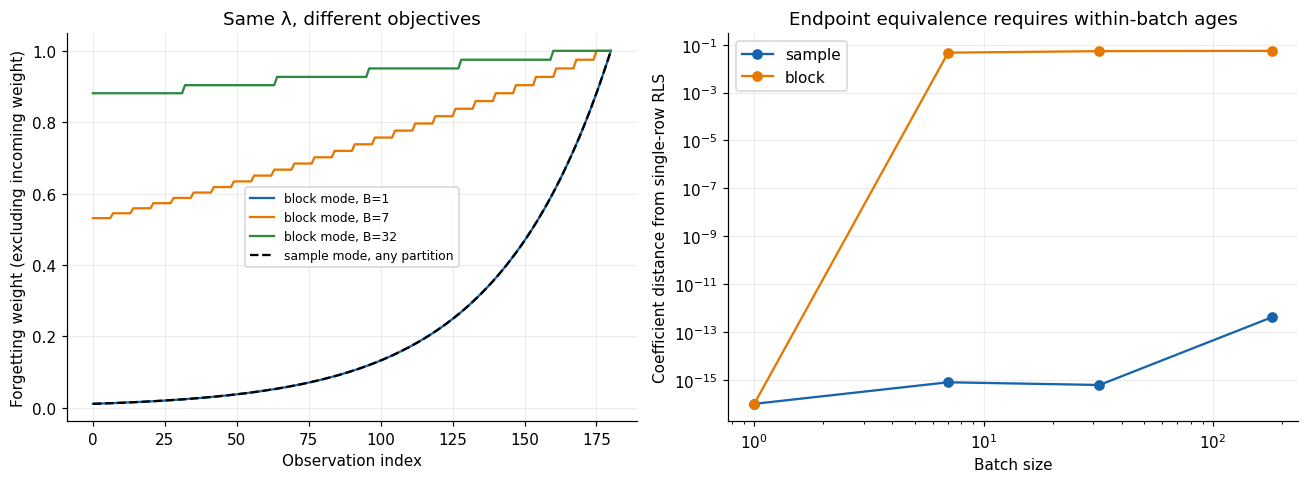

Sample-mode final states agree for batch sizes [1, 7, 32, 181]


In [6]:
rng = np.random.default_rng(442)
N = 181
Xp = np.column_stack((np.ones(N), rng.normal(size=(N,2))))
Yp = Xp @ np.array([[1.,-.5],[2.,1.],[-1.,.2]]) + rng.normal(0,.4,(N,2))
wp = rng.uniform(.4,2,N)
lam = .975; sizes = [1, 7, 32, 181]
partition_states = {}
for mode in ("sample", "block"):
    for size in sizes:
        e = BlockRLS(3,2,lam,ridge=.3,forgetting_mode=mode)
        e.fit(Xp,Yp,size,wp)
        partition_states[mode,size] = e
base = partition_states['sample',1]
for size in sizes:
    e = partition_states['sample',size]
    assert_allclose(e.Theta,base.Theta,atol=1e-11)
    assert_allclose(e.A_inv,base.A_inv,atol=1e-11)
assert np.linalg.norm(partition_states['block',32].Theta-base.Theta) > 1e-3

fig, axes = plt.subplots(1, 2, figsize=(12,4.5))
for j, size in enumerate((1,7,32)):
    ids = np.arange(N)//size
    weights = lam**(ids[-1]-ids)
    axes[0].plot(np.arange(N),weights,label=f"block mode, B={size}",color=COLORS[j])
axes[0].plot(np.arange(N),lam**(N-1-np.arange(N)),'k--',label="sample mode, any partition")
axes[0].set(xlabel="Observation index",ylabel="Forgetting weight (excluding incoming weight)",title="Same λ, different objectives")
axes[0].legend(fontsize=8)
for j, mode in enumerate(('sample','block')):
    errors=[max(np.linalg.norm(partition_states[mode,b].Theta-base.Theta),1e-16) for b in sizes]
    axes[1].plot(sizes,errors,'o-',label=mode,color=COLORS[j])
axes[1].set(xscale='log',yscale='log',xlabel='Batch size',ylabel='Coefficient distance from single-row RLS',title='Endpoint equivalence requires within-batch ages')
axes[1].legend()
show_figure(fig,'weighted-rls-forgetting')
print('Sample-mode final states agree for batch sizes',sizes)

## Tracking a Change in the Generating Parameters

Here the intercept and slope change abruptly halfway through the stream. Both models see exactly the same observations, and both predict each target before learning it. We use single-observation updates to avoid confusing batch prediction timing with adaptation. The forgetting model uses $\lambda=0.98$; the growing-window model uses $\lambda=1$.

Tracking is an application example rather than a substitute for the algebraic checks above. Consequently, we check both fitted paths against full weighted least squares at every update as well. The squared prediction-error curves are trailing averages that include the current prediction error and no future observations; the coefficient curves are the post-update states.

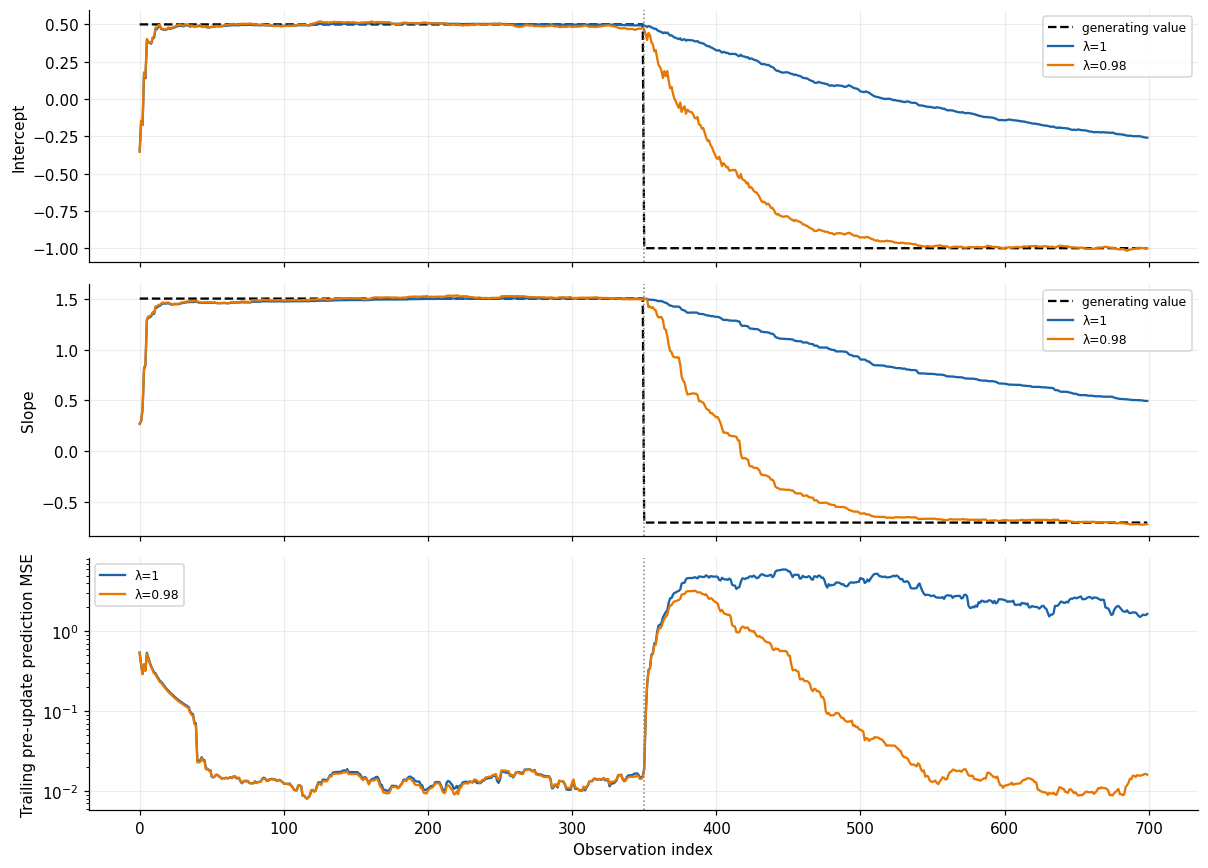

λ=1: last 100 predictions MSE=1.9922; final coefficient error=1.4051
λ=0.98: last 100 predictions MSE=0.0119; final coefficient error=0.0159


In [7]:
rng=np.random.default_rng(303)
N=700; change=350
Xd=np.column_stack((np.ones(N),rng.normal(size=N)))
before=np.array([.5,1.5]); after=np.array([-1.,-.7])
truth_d=np.where((np.arange(N)<change)[:,None],before,after)
Yd=np.sum(Xd*truth_d,axis=1)[:,None]+rng.normal(0,.12,(N,1))
paths={}; prediction_errors={}
for lam in (1.0,.98):
    checked,_=check_path(Xd,Yd,np.ones(N),1,lam=lam,rho=.5,mode='sample')
    e=BlockRLS(2,forgetting=lam,ridge=.5,forgetting_mode='sample')
    coefficients=[]; squared=[]
    for i in range(N):
        error=e.partial_fit(Xd[i:i+1],Yd[i:i+1])[0,0]
        squared.append(error**2); coefficients.append(e.Theta[:,0].copy())
    paths[lam]=np.asarray(coefficients); prediction_errors[lam]=np.asarray(squared)
    assert_allclose(e.Theta,checked.Theta,atol=1e-12)

def trailing_mean(values,window):
    sums=np.r_[0,np.cumsum(values)]
    ends=np.arange(1,len(values)+1); starts=np.maximum(ends-window,0)
    return (sums[ends]-sums[starts])/(ends-starts)

fig,axes=plt.subplots(3,1,figsize=(11,8),sharex=True)
for j,label in enumerate(('Intercept','Slope')):
    axes[j].plot(truth_d[:,j],'k--',label='generating value')
    for color,lam in zip(COLORS,(1.0,.98)):
        axes[j].plot(paths[lam][:,j],color=color,label=f'λ={lam:g}')
    axes[j].set(ylabel=label)
for color,lam in zip(COLORS,(1.0,.98)):
    axes[2].plot(trailing_mean(prediction_errors[lam],35),color=color,label=f'λ={lam:g}')
axes[2].set(xlabel='Observation index',ylabel='Trailing pre-update prediction MSE',yscale='log')
for ax in axes:
    ax.axvline(change,color='gray',ls=':',lw=1); ax.legend(fontsize=8)
show_figure(fig,'weighted-rls-drift')
for lam in (1.0,.98):
    print(f'λ={lam:g}: last 100 predictions MSE={prediction_errors[lam][-100:].mean():.4f}; '
          f'final coefficient error={np.linalg.norm(paths[lam][-1]-after):.4f}')
assert np.mean(prediction_errors[.98][-100:]) < np.mean(prediction_errors[1.0][-100:])

## Conditioning and an Unobserved Direction

The Woodbury identity is exact algebraically, but an inverse update can lose accuracy when the augmented design is poorly conditioned. We make two columns increasingly similar, use a small ridge, and compare both actual implementations with the full augmented least-squares reference. The horizontal axis is the condition number of the *augmented design*, rather than the unregularized design. The inverse-form implementation can explicitly reject a loss of positive definiteness; rejected cases are reported instead of silently replacing the model with a pseudoinverse.

A separate example repeatedly observes $[1,0]$. The second coefficient remains zero, but its inverse-normal diagonal grows as $1/(\rho\lambda^{n-1})$, because the data never constrain that direction and the ridge decays. This growth is part of the chosen objective. Symmetrization or switching to QR does not turn it into a fixed-ridge model.

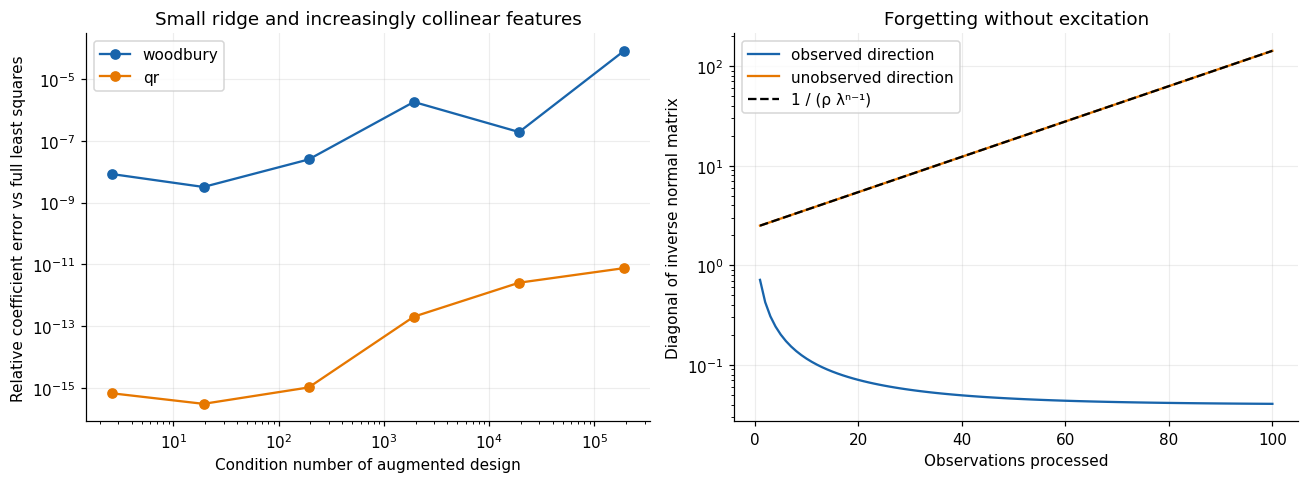

Relative coefficient errors: {'woodbury': [np.float64(8.422432104585676e-09), np.float64(3.2122014552469772e-09), np.float64(2.4948844680013377e-08), np.float64(1.809470555848187e-06), np.float64(1.9233987260943991e-07), np.float64(8.163040170919961e-05)], 'qr': [np.float64(6.799904511506934e-16), np.float64(3.0914428523524034e-16), np.float64(1.047646646298683e-15), np.float64(2.0443235232056717e-13), np.float64(2.569301072981259e-12), np.float64(7.604159551015398e-12)]}
Explicitly rejected cases: none in this run


In [8]:
rng=np.random.default_rng(804)
base_x=rng.normal(size=160); perturb=rng.normal(size=160)
noise=rng.normal(0,.01,(160,1))
rho=1e-10
conditions=[]; conditioning_errors={s:[] for s in ('woodbury','qr')}; rejected=[]
for epsilon in (1.,1e-1,1e-2,1e-3,1e-4,1e-5):
    Xc=np.column_stack((np.ones(160),base_x,base_x+epsilon*perturb))
    Yc=Xc @ np.array([[.5],[2.],[-1.]])+noise
    ref,_,_,_=full_reference(Xc,Yc,np.ones(160),rho)
    augmented=np.vstack((Xc,np.sqrt(rho)*np.eye(3)))
    conditions.append(np.linalg.cond(augmented))
    for solver in conditioning_errors:
        e=BlockRLS(3,ridge=rho,solver=solver)
        try:
            e.fit(Xc,Yc,batch_size=17)
            conditioning_errors[solver].append(np.linalg.norm(e.Theta-ref)/max(np.linalg.norm(ref),1.))
        except (np.linalg.LinAlgError,FloatingPointError) as exc:
            conditioning_errors[solver].append(np.nan)
            rejected.append((solver,epsilon,str(exc)))
assert np.nanmax(conditioning_errors['qr']) < 1e-5

unobserved=BlockRLS(2,forgetting=.96,ridge=.4)
uncertainty=[]
for i in range(100):
    unobserved.partial_fit([[1,0]],[2])
    uncertainty.append(np.diag(unobserved.A_inv))
uncertainty=np.asarray(uncertainty)
expected=1/(.4*.96**np.arange(100))
assert_allclose(uncertainty[:,1],expected,rtol=2e-12)
fig,axes=plt.subplots(1,2,figsize=(12,4.5))
for color,solver in zip(COLORS,conditioning_errors):
    axes[0].loglog(conditions,np.maximum(conditioning_errors[solver],1e-17),'o-',color=color,label=solver)
axes[0].set(xlabel='Condition number of augmented design',ylabel='Relative coefficient error vs full least squares',title='Small ridge and increasingly collinear features')
axes[0].legend()
axes[1].semilogy(np.arange(1,101),uncertainty[:,0],label='observed direction',color=COLORS[0])
axes[1].semilogy(np.arange(1,101),uncertainty[:,1],label='unobserved direction',color=COLORS[1])
axes[1].semilogy(np.arange(1,101),expected,'k--',label='1 / (ρ λⁿ⁻¹)')
axes[1].set(xlabel='Observations processed',ylabel='Diagonal of inverse normal matrix',title='Forgetting without excitation')
axes[1].legend()
show_figure(fig,'weighted-rls-conditioning')
print('Relative coefficient errors:',conditioning_errors)
print('Explicitly rejected cases:',rejected or 'none in this run')

## Residual Covariance and Scores without Current-batch Leakage

The module also contains a weighted Gaussian estimator for the RLS residuals. Its inverse is initialized only after the accumulated centered scatter has enough rank and acceptable conditioning. Earlier scores are `NaN`, not zero or a distance computed from the very batch being scored. This permits batches smaller than the output dimension; a centered batch of $B$ rows has rank at most $B-1$, and even a larger batch can be rank deficient.

The reliability-weight covariance denominator is $W-W_2/W$, with $W_2=\sum_iw_i^2$. The paired `covariance_` and `precision_` use that same denominator. Population-normalized scores use $\mathbf M/W$, and the old mean and precision are used for the entire incoming batch. We check both inverse-update modes against explicit weighted moments on offset data and against NumPy's weighted covariance. Unbiasedness of the reliability-weight correction assumes fixed weights and independent observations with a common covariance; fitted residuals do not automatically meet those assumptions.

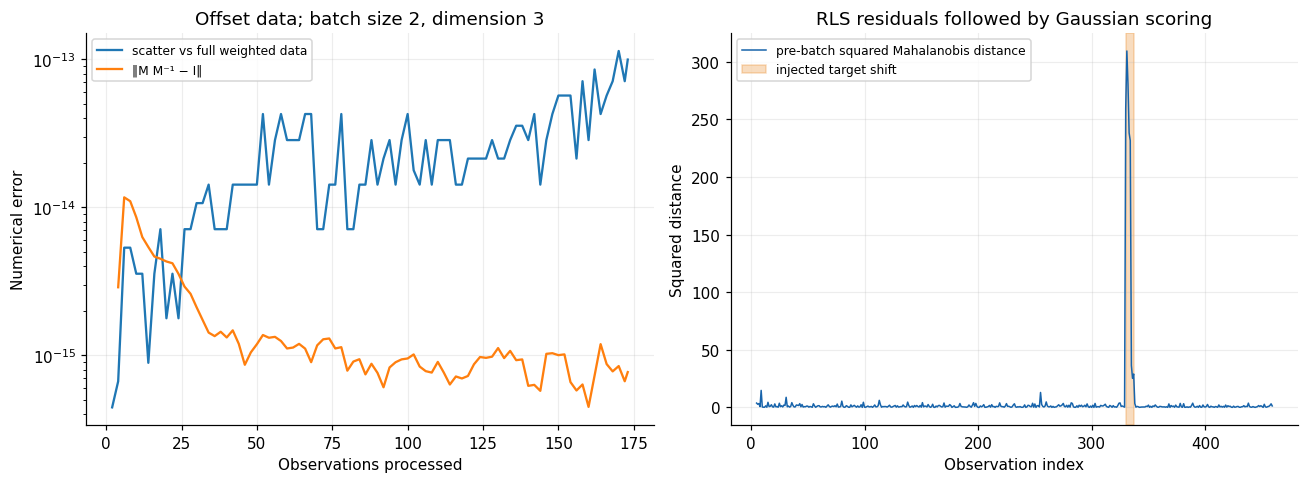

87 weighted moment prefixes passed; inverse remained unavailable during singular warm-up.
Pipeline warm-up NaNs: 5
Median baseline score (rows 150–299): 0.7873977856416186
Maximum score at injected shift: 309.3713517075083


In [9]:
rng=np.random.default_rng(502)
Z=rng.multivariate_normal([2.,-3.,1.],[[2.,.6,-.2],[.6,1.,.1],[-.2,.1,.7]],size=173)
weights=rng.uniform(.4,2,len(Z)); lam=.96; size=2
g=WeightedGaussian(3,lam,'woodbury'); direct=WeightedGaussian(3,lam,'direct')
labels=np.empty(len(Z),int); moment_errors=[]; inverse_errors=[]; scored=[]; checks_gaussian=0
for j,(a,b) in enumerate(iter_blocks(len(Z),size)):
    pre=g.score_samples(Z[a:b])
    scores=g.partial_fit(Z[a:b],weights[a:b]); direct.partial_fit(Z[a:b],weights[a:b])
    assert_allclose(scores,pre,atol=1e-11)
    scored.extend(scores); labels[a:b]=j
    w=weights[:b]*lam**(j-labels[:b])
    mean=np.average(Z[:b],axis=0,weights=w)
    centered=Z[:b]-mean; scatter=centered.T @ (w[:,None]*centered)
    assert_allclose(g.mean_,mean,atol=1e-12)
    assert_allclose(g.M,scatter,atol=1e-11)
    assert_allclose(g.covariance_,np.cov(Z[:b],rowvar=False,aweights=w),atol=1e-11)
    moment_errors.append((b,np.max(np.abs(g.M-scatter))))
    if g.M_inv is not None:
        assert_allclose(g.M_inv,direct.M_inv,rtol=1e-8,atol=1e-9)
        assert_allclose(g.covariance_ @ g.precision_,np.eye(3),atol=1e-8)
        inverse_errors.append((b,np.linalg.norm(g.M @ g.M_inv-np.eye(3))))
    checks_gaussian+=1
scored=np.asarray(scored)
assert np.isnan(scored[:2]).all()
assert np.isfinite(scored[-100:]).all()
assert np.all(scored[np.isfinite(scored)]>=0)

# A small anomaly-scoring example: the anomaly is learned only after its score.
rng=np.random.default_rng(503)
Ns=460
Xs=np.column_stack((np.sin(np.arange(Ns)*.035),rng.normal(size=Ns)))
Ys=Xs @ np.array([[1.,-.5],[.3,1.2]]) + rng.normal(0,.12,(Ns,2))
Ys[330:338,0]+=2.0
pipeline=residual_anomaly_scores(Xs,Ys,forgetting=.98,batch_size=5,ridge=.2)
assert pipeline['residuals'].shape==Ys.shape
assert pipeline['rls'].n_samples_seen==Ns
assert pipeline['gauss'].n_samples_seen==Ns
scores=pipeline['scores']
fig,axes=plt.subplots(1,2,figsize=(12,4.5))
rows=np.asarray(moment_errors); invrows=np.asarray(inverse_errors)
axes[0].semilogy(rows[:,0],np.maximum(rows[:,1],1e-17),label='scatter vs full weighted data')
axes[0].semilogy(invrows[:,0],np.maximum(invrows[:,1],1e-17),label='‖M M⁻¹ − I‖')
axes[0].set(xlabel='Observations processed',ylabel='Numerical error',title='Offset data; batch size 2, dimension 3')
axes[0].legend(fontsize=8)
axes[1].plot(scores,color=COLORS[0],lw=1,label='pre-batch squared Mahalanobis distance')
axes[1].axvspan(330,337,color=COLORS[1],alpha=.25,label='injected target shift')
axes[1].set(xlabel='Observation index',ylabel='Squared distance',title='RLS residuals followed by Gaussian scoring')
axes[1].legend(fontsize=8)
show_figure(fig,'weighted-rls-residuals')
print(f'{checks_gaussian} weighted moment prefixes passed; inverse remained unavailable during singular warm-up.')
print('Pipeline warm-up NaNs:',np.isnan(scores).sum())
print('Median baseline score (rows 150–299):',np.nanmedian(scores[150:300]))
print('Maximum score at injected shift:',np.nanmax(scores[330:338]))
assert np.nanmax(scores[330:338]) > 10*np.nanmedian(scores[150:300])

The pipeline learns from every incoming batch, including the injected anomaly. Accordingly, the example illustrates scoring order and the response to a change; it is not a benchmark of an anomaly-rejection policy. We have not chosen a detection threshold, claimed a false-alarm rate, or assumed that the residuals have an exact chi-square calibration.

## Invalid Inputs and Reproducibility

The reference rejects nonfinite data, nonpositive weights and inconsistent shapes before updating state. A flat target array is interpreted using the declared number of outputs, which avoids silently broadcasting one target across several output columns. The checks below also exercise an empty `fit`, a short remainder and continuation of an existing fit. A separate regression-test module remains in the blog repository; this notebook embeds its own implementation so the version being demonstrated is inspectable in Colab.

In [10]:
e=BlockRLS(2)
e.partial_fit([[1.,2.]],[3.])
saved_theta,saved_P=e.Theta.copy(),e.A_inv
for data,target,weights in [([[np.nan,1.]],[2.],None),([[1.,2.]],[np.inf],None),
                            ([[1.,2.]],[2.],[0.]),([[1.,2.]],[2.],[-1.])]:
    try:
        e.partial_fit(data,target,weights)
    except ValueError:
        pass
    else:
        raise AssertionError('Invalid input was accepted')
    assert_allclose(e.Theta,saved_theta); assert_allclose(e.A_inv,saved_P)
assert e.fit(np.empty((0,2)),np.empty(0)).shape==(0,1)
assert list(iter_blocks(11,4))==[(0,4),(4,8),(8,11)]

VALIDATION_SUMMARY={
    'grid_prefix_comparisons':int(checks),
    'grid_max_coefficient_error':float(worst_theta),
    'grid_max_inverse_error':float(worst_inverse),
    'gaussian_prefix_comparisons':int(checks_gaussian),
    'weighted_parameter_mse':parameter_mse.mean(axis=0).tolist(),
    'drift_final_100_mse':{str(lam):float(values[-100:].mean()) for lam,values in prediction_errors.items()},
    'qr_conditioning_max_relative_error':float(np.nanmax(conditioning_errors['qr'])),
    'all_assertions_passed':True,
}
print('All notebook assertions passed.')
for name,value in VALIDATION_SUMMARY.items():
    print(f'{name}: {value}')
if EXPORT_DIR:
    import json
    (Path(EXPORT_DIR)/'validation-summary.json').write_text(json.dumps(VALIDATION_SUMMARY,indent=2)+'\n')

All notebook assertions passed.
grid_prefix_comparisons: 3680
grid_max_coefficient_error: 9.270362255620057e-15
grid_max_inverse_error: 7.771561172376096e-15
gaussian_prefix_comparisons: 87
weighted_parameter_mse: [0.0015019400866616282, 5.9876603405417463e-05]
drift_final_100_mse: {'1.0': 1.992225465951847, '0.98': 0.01191840288170603}
qr_conditioning_max_relative_error: 7.604159551015398e-12
all_assertions_passed: True


## What the Checks Establish

For the tested, well-conditioned streams, both recursive formulations agree with the separately assembled weighted least-squares solution at every update. Positive observation weights, multiple outputs, incomplete batches and the first-update ridge convention are included in those comparisons. Exact per-observation forgetting also agrees across different partitions, while equal-weight batch forgetting intentionally defines a different objective. The nearly collinear example exposes finite-precision limitations instead of using parameter recovery alone as evidence of correctness.

The notebook's full-data oracle stores and refits observation history for validation; the `partial_fit` estimators themselves do not retain it. `fit` returns all residuals and therefore uses output storage proportional to the input length. The dense Joseph and QR implementations favor clarity and checks over minimum computation time, and no runtime benchmark is claimed. Very long streams, extreme weights and vanishing excitation still require application-specific numerical monitoring.

References: the complete derivation is given in the accompanying blog post. The independent oracle uses [NumPy least squares](https://numpy.org/doc/stable/reference/generated/numpy.linalg.lstsq.html), and the updates use [linear solves](https://numpy.org/doc/stable/reference/generated/numpy.linalg.solve.html).